# Model training — sanity check on the gold stores

Fits a binary default classifier on `datamart/gold/features_store` (X) and `datamart/gold/label_store` (y) to prove the feature store is ML-compatible and leak-free. Structure follows `week-4/lab_3/model_train_main.ipynb`.

* **Label**: `30dpd_6mob`; label `snapshot_date` = loan start + 6 months.
* **Features**: one row per applicant at application time (`snapshot_date` = loan start).
* **Join**: `features.snapshot_date == labels.snapshot_date - 6 months`, so every feature is known at application time.
* **Split**: by label date — train/test before the OOT window, OOT = last months. All preprocessing is fitted on train only.

In [1]:
import os
import pickle
import pprint
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from dateutil.relativedelta import relativedelta
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# run from the repo root so datamart/ resolves (Jupyter starts in notebooks/)
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

## Set up config

In [2]:
model_train_date_str = "2025-08-01"  # first day after the latest label month
oot_period_months = 3
train_test_ratio = 0.8
LABEL_MOB = 6

config = {}
config["model_train_date_str"] = model_train_date_str
config["oot_period_months"] = oot_period_months
config["model_train_date"] = datetime.strptime(model_train_date_str, "%Y-%m-%d")
config["oot_end_date"] = config["model_train_date"] - timedelta(days=1)
config["oot_start_date"] = config["model_train_date"] - relativedelta(months=oot_period_months)
config["train_test_end_date"] = config["oot_start_date"] - timedelta(days=1)
config["train_test_ratio"] = train_test_ratio
pprint.pprint(config)

{'model_train_date': datetime.datetime(2025, 8, 1, 0, 0),
 'model_train_date_str': '2025-08-01',
 'oot_end_date': datetime.datetime(2025, 7, 31, 0, 0),
 'oot_period_months': 3,
 'oot_start_date': datetime.datetime(2025, 5, 1, 0, 0),
 'train_test_end_date': datetime.datetime(2025, 4, 30, 0, 0),
 'train_test_ratio': 0.8}


## Get labels and features

In [3]:
labels = pd.read_parquet("datamart/gold/label_store")
features = pd.read_parquet("datamart/gold/features_store")
print("labels", labels.shape, "| features", features.shape)
print("label_def", labels["label_def"].unique())

labels = labels.rename(columns={"snapshot_date": "label_date"})
labels["label_date"] = pd.to_datetime(labels["label_date"])
labels["loan_start_date"] = labels["label_date"] - pd.DateOffset(months=LABEL_MOB)
features["snapshot_date"] = pd.to_datetime(features["snapshot_date"])

# only labels already observed at training time
labels = labels[labels["label_date"] <= config["oot_end_date"]]

assert labels["loan_id"].is_unique
assert not features.duplicated(["customer_id", "snapshot_date"]).any()

labels (12500, 5) | features (12500, 45)
label_def <ArrowStringArray>
['30dpd_6mob']
Length: 1, dtype: str


## Prepare data for modeling

In [4]:
data_pdf = labels.merge(features, left_on=["customer_id", "loan_start_date"],
                        right_on=["customer_id", "snapshot_date"], how="left")
print("joined", data_pdf.shape, "| unmatched labels:", data_pdf["snapshot_date"].isna().sum())

# leakage guard: features dated at loan start, strictly before the label is observed
assert (data_pdf["snapshot_date"] == data_pdf["loan_start_date"]).all()
assert (data_pdf["snapshot_date"] < data_pdf["label_date"]).all()

ID_COLS = ["loan_id", "customer_id", "label", "label_def", "label_date", "loan_start_date", "snapshot_date"]
X_all = data_pdf.drop(columns=ID_COLS)
numeric_cols = X_all.select_dtypes("number").columns.tolist()
categorical_cols = [c for c in X_all.columns if c not in numeric_cols]
feature_cols = numeric_cols + categorical_cols
print(len(numeric_cols), "numeric:", numeric_cols)
print(len(categorical_cols), "categorical:", categorical_cols)

joined (12500, 50) | unmatched labels: 0
40 numeric: ['age', 'annual_income', 'monthly_inhand_salary', 'num_bank_accounts', 'num_credit_card', 'interest_rate', 'num_of_loan', 'delay_from_due_date', 'num_of_delayed_payment', 'changed_credit_limit', 'num_credit_inquiries', 'outstanding_debt', 'credit_utilization_ratio', 'total_emi_per_month', 'amount_invested_monthly', 'monthly_balance', 'spend_level', 'payment_value', 'credit_history_months', 'fe_1_mean_6m', 'fe_2_mean_6m', 'fe_3_mean_6m', 'fe_4_mean_6m', 'fe_5_mean_6m', 'fe_6_mean_6m', 'fe_7_mean_6m', 'fe_8_mean_6m', 'fe_9_mean_6m', 'fe_10_mean_6m', 'fe_11_mean_6m', 'fe_12_mean_6m', 'fe_13_mean_6m', 'fe_14_mean_6m', 'fe_15_mean_6m', 'fe_16_mean_6m', 'fe_17_mean_6m', 'fe_18_mean_6m', 'fe_19_mean_6m', 'fe_20_mean_6m', 'has_clickstream']
3 categorical: ['occupation', 'credit_mix', 'payment_of_min_amount']


In [5]:
# split data into train - test - oot (by label date, never random across time)
oot_pdf = data_pdf[data_pdf["label_date"] >= config["oot_start_date"]]
train_test_pdf = data_pdf[data_pdf["label_date"] <= config["train_test_end_date"]]

X_oot, y_oot = oot_pdf[feature_cols], oot_pdf["label"]
X_train, X_test, y_train, y_test = train_test_split(
    train_test_pdf[feature_cols], train_test_pdf["label"],
    test_size=1 - config["train_test_ratio"],
    random_state=88,
    shuffle=True,
    stratify=train_test_pdf["label"],
)

for name, X, y in [("train", X_train, y_train), ("test", X_test, y_test), ("oot", X_oot, y_oot)]:
    print(f"{name:5s} rows={X.shape[0]:5d} default_rate={y.mean():.3f}")
print("train/test label dates:", train_test_pdf["label_date"].min().date(), "->", train_test_pdf["label_date"].max().date())
print("oot label dates:       ", oot_pdf["label_date"].min().date(), "->", oot_pdf["label_date"].max().date())

train rows= 8776 default_rate=0.290
test  rows= 2195 default_rate=0.290
oot   rows= 1529 default_rate=0.273
train/test label dates: 2023-07-01 -> 2025-04-01
oot label dates:        2025-05-01 -> 2025-07-01


## Preprocessing

Fitted on **train only** (avoids train-test contamination), then applied to test and OOT.
* XGBoost handles missing values natively, so numerics pass through; categoricals are one-hot encoded with `handle_unknown="ignore"` so unseen levels in OOT don't break inference.
* Logistic regression baseline additionally needs imputation + scaling.

In [6]:
def categorical_pipe():
    return make_pipeline(SimpleImputer(strategy="constant", fill_value="missing"),
                         OneHotEncoder(handle_unknown="ignore", sparse_output=False))

xgb_preprocessor = ColumnTransformer([
    ("num", "passthrough", numeric_cols),
    ("cat", categorical_pipe(), categorical_cols),
])
lr_preprocessor = ColumnTransformer([
    ("num", make_pipeline(SimpleImputer(strategy="median"), StandardScaler()), numeric_cols),
    ("cat", categorical_pipe(), categorical_cols),
])

X_train_processed = xgb_preprocessor.fit_transform(X_train)
X_test_processed = xgb_preprocessor.transform(X_test)
X_oot_processed = xgb_preprocessor.transform(X_oot)
processed_feature_names = xgb_preprocessor.get_feature_names_out()
print("X_train_processed", X_train_processed.shape)
print("X_test_processed ", X_test_processed.shape)
print("X_oot_processed  ", X_oot_processed.shape)

X_train_processed (8776, 63)
X_test_processed  (2195, 63)
X_oot_processed   (1529, 63)


## Baseline: logistic regression

In [7]:
def gini(y, p):
    return 2 * roc_auc_score(y, p) - 1

lr_model = make_pipeline(lr_preprocessor, LogisticRegression(max_iter=2000))
lr_model.fit(X_train, y_train)
for name, X, y in [("train", X_train, y_train), ("test", X_test, y_test), ("oot", X_oot, y_oot)]:
    print(f"LR {name:5s} GINI: {gini(y, lr_model.predict_proba(X)[:, 1]):.3f}")

LR train GINI: 0.678
LR test  GINI: 0.709


LR oot   GINI: 0.533


## Train model: XGBoost + random search

In [8]:
xgb_clf = xgb.XGBClassifier(eval_metric="logloss", random_state=88)

param_dist = {
    "n_estimators": [50, 100, 200],
    "max_depth": [2, 3, 4],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.6, 0.8],
    "colsample_bytree": [0.6, 0.8],
    "gamma": [0, 0.1],
    "min_child_weight": [1, 3, 5],
    "reg_alpha": [0, 0.1, 1],
    "reg_lambda": [1, 1.5, 2],
}

random_search = RandomizedSearchCV(
    estimator=xgb_clf,
    param_distributions=param_dist,
    scoring="roc_auc",  # uses predicted probabilities, not hard 0/1 labels
    n_iter=30,
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1,
)
random_search.fit(X_train_processed, y_train)

print("Best parameters found:", random_search.best_params_)
print("Best CV AUC:", round(random_search.best_score_, 3))

Fitting 3 folds for each of 30 candidates, totalling 90 fits


Best parameters found: {'subsample': 0.8, 'reg_lambda': 1, 'reg_alpha': 1, 'n_estimators': 200, 'min_child_weight': 3, 'max_depth': 3, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 0.8}
Best CV AUC: 0.853


In [9]:
best_model = random_search.best_estimator_
results = {}
for name, X, y in [("train", X_train_processed, y_train), ("test", X_test_processed, y_test), ("oot", X_oot_processed, y_oot)]:
    auc = roc_auc_score(y, best_model.predict_proba(X)[:, 1])
    results[f"auc_{name}"] = auc
    results[f"gini_{name}"] = round(2 * auc - 1, 3)
    print(f"XGB {name:5s} AUC: {auc:.3f}  GINI: {2 * auc - 1:.3f}")

XGB train AUC: 0.918  GINI: 0.836
XGB test  AUC: 0.872  GINI: 0.744
XGB oot   AUC: 0.811  GINI: 0.623


## Leakage check: feature importance

If one feature dominated (or train GINI ≫ OOT GINI), that would hint at leakage. A spread of importance across financial / behavioural features and a small train→OOT gap indicate the store only holds information available at application time.

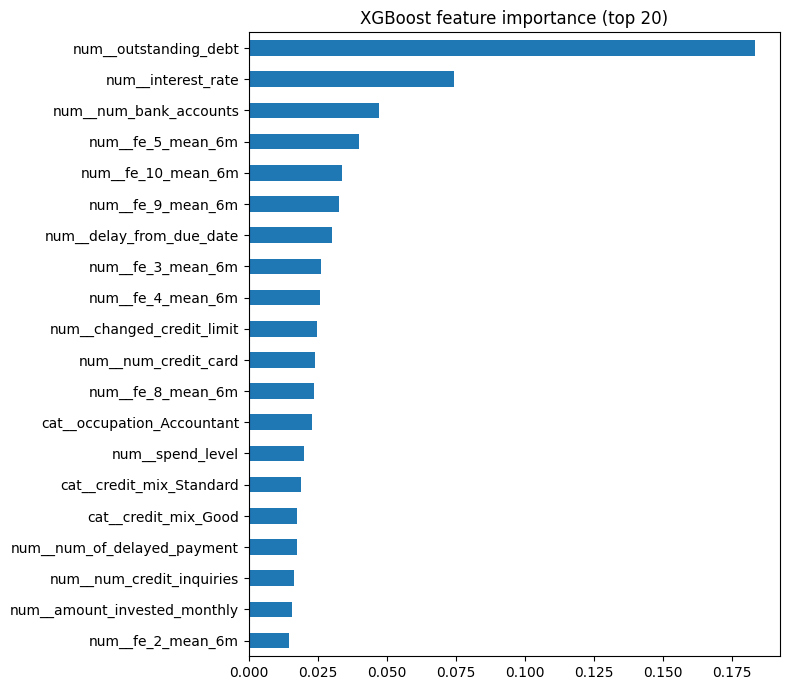

num__outstanding_debt        0.183
num__interest_rate           0.074
num__num_bank_accounts       0.047
num__fe_5_mean_6m            0.040
num__fe_10_mean_6m           0.034
num__fe_9_mean_6m            0.033
num__delay_from_due_date     0.030
num__fe_3_mean_6m            0.026
num__fe_4_mean_6m            0.026
num__changed_credit_limit    0.025
dtype: float32

In [10]:
importance = pd.Series(best_model.feature_importances_, index=processed_feature_names).sort_values()
importance.tail(20).plot.barh(figsize=(8, 7), title="XGBoost feature importance (top 20)")
plt.tight_layout(); plt.show()
importance.sort_values(ascending=False).head(10).round(3)

In [11]:
# stability across time: OOT GINI per label month
oot_scored = oot_pdf.assign(score=best_model.predict_proba(X_oot_processed)[:, 1])
oot_scored.groupby(oot_scored["label_date"].dt.date).apply(
    lambda g: pd.Series({"loans": len(g), "default_rate": g["label"].mean(), "gini": gini(g["label"], g["score"])})
).round(3)

,loans,default_rate,gini
label_date,,,
2025-05-01,488.0,0.281,0.635
2025-06-01,515.0,0.272,0.681
2025-07-01,526.0,0.268,0.560


## Prepare model artefact to save

In [12]:
model_artefact = {
    "model": best_model,
    "model_version": "credit_model_" + config["model_train_date_str"].replace("-", "_"),
    "preprocessing_transformers": {"column_transformer": xgb_preprocessor},
    "feature_cols": feature_cols,
    "data_dates": config,
    "data_stats": {
        "X_train": X_train.shape[0], "X_test": X_test.shape[0], "X_oot": X_oot.shape[0],
        "y_train": round(y_train.mean(), 2), "y_test": round(y_test.mean(), 2), "y_oot": round(y_oot.mean(), 2),
    },
    "results": results,
    "hp_params": random_search.best_params_,
}
pprint.pprint({k: v for k, v in model_artefact.items() if k not in ("model", "preprocessing_transformers")})

{'data_dates': {'model_train_date': datetime.datetime(2025, 8, 1, 0, 0),
                'model_train_date_str': '2025-08-01',
                'oot_end_date': datetime.datetime(2025, 7, 31, 0, 0),
                'oot_period_months': 3,
                'oot_start_date': datetime.datetime(2025, 5, 1, 0, 0),
                'train_test_end_date': datetime.datetime(2025, 4, 30, 0, 0),
                'train_test_ratio': 0.8},
 'data_stats': {'X_oot': 1529,
                'X_test': 2195,
                'X_train': 8776,
                'y_oot': np.float64(0.27),
                'y_test': np.float64(0.29),
                'y_train': np.float64(0.29)},
 'feature_cols': ['age',
                  'annual_income',
                  'monthly_inhand_salary',
                  'num_bank_accounts',
                  'num_credit_card',
                  'interest_rate',
                  'num_of_loan',
                  'delay_from_due_date',
                  'num_of_delayed_payment',
            

## Save artefact to model bank

In [13]:
model_bank_directory = "model_bank/"
os.makedirs(model_bank_directory, exist_ok=True)
file_path = os.path.join(model_bank_directory, model_artefact["model_version"] + ".pkl")
with open(file_path, "wb") as file:
    pickle.dump(model_artefact, file)
print(f"Model saved to {file_path}")

Model saved to model_bank/credit_model_2025_08_01.pkl


## Test load pickle and make model inference

In [14]:
with open(file_path, "rb") as file:
    loaded_model_artefact = pickle.load(file)

X_oot_reprocessed = loaded_model_artefact["preprocessing_transformers"]["column_transformer"].transform(
    X_oot[loaded_model_artefact["feature_cols"]])
y_pred_proba = loaded_model_artefact["model"].predict_proba(X_oot_reprocessed)[:, 1]
print("OOT AUC score:", round(roc_auc_score(y_oot, y_pred_proba), 3))
print("Model loaded successfully!")

OOT AUC score: 0.811
Model loaded successfully!
